# DESEMPAQUETADOR

In [ ]:
import numpy as np
from tensorflow.keras.utils import to_categorical

# 1. Definir la ruta de tu archivo (usando la ruta que mostró tu consola)
archivo_npz = '/content/dataset_fallrisk_listo.npz'

# 2. Cargar el archivo .npz
print(f"⏳ Desempaquetando datos desde: {archivo_npz}...")
datos = np.load(archivo_npz)

# 3. Extraer los arrays (¡Ya están divididos!)
X_train = datos['X_train']
y_train = datos['y_train']
X_val = datos['X_val']
y_val = datos['y_val']

print(f"\n📊 Forma de X_train (Entrenamiento): {X_train.shape}")
print(f"📊 Forma de X_val (Validación): {X_val.shape}")

# 4. Codificación de las etiquetas (One-Hot Encoding)
# Como la red necesita [1, 0] para ADL y [0, 1] para Caída:
# num_clases = len(np.unique(y_train)) # Ver cuántas clases únicas hay (deberían ser 2)

# y_train_cat = to_categorical(y_train, num_classes=num_clases)
# y_val_cat = to_categorical(y_val, num_classes=num_clases)

print("\n✅ --- RESUMEN DE LA PREPARACIÓN PARA LA CNN+LSTM --- ✅")
print(f"Entrenamiento (Train) -> X: {X_train.shape} | y: {y_train.shape}")
print(f"Validación (Val)    -> X: {X_val.shape}   | y: {y_val.shape}")

⏳ Desempaquetando datos desde: /content/dataset_fallrisk_listo.npz...

📊 Forma de X_train (Entrenamiento): (112913, 100, 6)
📊 Forma de X_val (Validación): (28229, 100, 6)

✅ --- RESUMEN DE LA PREPARACIÓN PARA LA CNN+LSTM --- ✅
Entrenamiento (Train) -> X: (112913, 100, 6) | y: (112913,)
Validación (Val)    -> X: (28229, 100, 6)   | y: (28229,)


# MODELO CNN + LSTM (CONFIG)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Bidirectional, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# =====================================================================
# 0. CONFIGURACION DE FOCAL LOSS PARA METRICAS DE ENTRENAMIENTO
# =====================================================================

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        pt_1 = tf.where(tf.equal(y_true, 1), y_pred, tf.ones_like(y_pred))
        pt_0 = tf.where(tf.equal(y_true, 0), y_pred, tf.zeros_like(y_pred))
        return -tf.reduce_sum(alpha * tf.pow(1. - pt_1, gamma) * tf.math.log(pt_1))-tf.reduce_sum((1-alpha) * tf.pow( pt_0, gamma) * tf.math.log(1. - pt_0))
    return focal_loss_fixed

# =====================================================================
# 1. CONFIGURACIÓN GENERAL (Aísla tus hiperparámetros aquí)
# =====================================================================
CONFIG = {
    "WINDOW_SIZE": 100,       # 100 muestras de tiempo (2 segundos a 50 Hz)
    "NUM_SENSORS": 6,         # Canales/Sensores (3 Acelerómetro + 3 Giroscopio)
    "BATCH_SIZE": 128,        # Tamaño del lote para procesar en paralelo
    "EPOCHS": 300,            # Épocas máximas de entrenamiento
    "LEARNING_RATE": 1e-4,    # Tasa de aprendizaje (ajuste fino óptimo)
    "NUM_CLASSES": 1          # 2 clases utilizando One-Hot Encoding ([1,0] o [0,1]) , para este caso sigmoide 1
}

# =====================================================================
# 2. ARQUITECTURA DE LA RED NEURONAL (Modular y Escalable)
# =====================================================================
def crear_modelo_cnn_lstm(config_dict):
    """
    Construye y compila el modelo secuencial espacio-temporal
    basado en los parámetros provistos en el diccionario de configuración.
    """
    model = Sequential([
        # --- Bloque CNN 1: Extractor de Características Locales ---
        # El input_shape se alimenta directamente desde nuestra CONFIG
        Conv1D(filters=32, kernel_size=3, activation='relu',
               input_shape=(config_dict["WINDOW_SIZE"], config_dict["NUM_SENSORS"]),
               name="conv1d_capa_1"),
        MaxPooling1D(pool_size=2, name="maxpool_capa_1"),

        # --- Bloque CNN 2: Extractor de Características Complejas ---
        Conv1D(filters=64, kernel_size=3, activation='relu', name="conv1d_capa_2"),
        MaxPooling1D(pool_size=2, name="maxpool_capa_2"),

        # --- Capa de Regularización (Evita que el modelo memorice) ---
        Dropout(0.2, name="dropout_regularizacion"),

        # --- Cerebro Recurrente: Analiza la secuencia histórica ---
        # Recuerda: NO usamos Flatten antes de la LSTM para mantener el orden del tiempo
        # LSTM(units=64, name="lstm_temporal"),

        # Agregamos una variacion para BILSTM
        tf.keras.layers.Bidirectional( tf.keras.layers.LSTM(units=64), name="bilstm_temporal"),

        # NUEVO: Capa intermedia para analizar los datos de la LSTM
        Dense(units=32, activation='relu', name="comite_denso_intermedio"),
        Dropout(0.2, name="dropout_final"), # Evita memorizar

        # --- Clasificador de Salida ---
        # 2 unidades con activación Softmax para darnos un porcentaje probabilístico
        # Dense(units=config_dict["NUM_CLASSES"], activation='softmax', name="salida_probabilidades")
        # Esto si fuera para clasificacion con mas variables
        Dense(units=1, activation='sigmoid', name="salida_probabilidad_caida")

    ], name="Modelo_Deteccion_Caidas_HAR")

    # Configuramos el optimizador Adam con el Learning Rate de la configuración
    optimizador = Adam(learning_rate=config_dict["LEARNING_RATE"])

    # Compilamos el modelo definiendo la función de error y la métrica de éxito
    model.compile(
        optimizer=optimizador,
        loss=focal_loss(gamma=2.0, alpha=0.25),
        #loss='binary_crossentropy',        # Ideal para etiquetar binario
        metrics=['accuracy']               # Monitorea la precisión época a época
    )

    return model

# ALTERNATIVA   2.0

def crear_modelo_multihead_cnn_bilstm(config_dict):
    """
    Construye el modelo usando la API Funcional de Keras para permitir
    el mecanismo de Atención Multi-Cabezal.
    """
    # 1. Capa de Entrada (Requisito de la API Funcional)
    inputs = Input(shape=(config_dict["WINDOW_SIZE"], config_dict["NUM_SENSORS"]), name="entrada_sensores")

    # --- Bloque CNN (Extractor Espacial) ---
    x = Conv1D(filters=32, kernel_size=3, activation='relu', name="conv1d_capa_1")(inputs)
    x = MaxPooling1D(pool_size=2, name="maxpool_capa_1")(x)

    x = Conv1D(filters=64, kernel_size=3, activation='relu', name="conv1d_capa_2")(x)
    x = MaxPooling1D(pool_size=2, name="maxpool_capa_2")(x)

    x = Dropout(0.2, name="dropout_cnn")(x)

    # --- Bloque BiLSTM ---
    # CRÍTICO: return_sequences=True para pasarle TODA la línea de tiempo a la capa de Atención
    x = Bidirectional(LSTM(units=64, return_sequences=True), name="bilstm_temporal")(x)

    # --- NUEVO: Mecanismo Multi-Head Attention (Self-Attention) ---
    # num_heads=3 (Nuestros 3 detectives), key_dim=64 (Tamaño de la memoria de cada cabeza)
    # Se le pasa 'x' como query y value (Self-Attention)
    atencion = MultiHeadAttention(num_heads=3, key_dim=64, name="atencion_multicabezal")(x, x)

    # --- Compresión Final ---
    # En lugar de Flatten, usamos GlobalAveragePooling1D que es más eficiente y moderno
    # Toma los vectores ponderados por la atención y los promedia para la decisión final
    x = GlobalAveragePooling1D(name="compresion_global")(atencion)

    # --- Comitê Denso y Clasificador de Salida ---
    x = Dense(units=32, activation='relu', name="comite_denso_intermedio")(x)
    x = Dropout(0.2, name="dropout_final")(x)

    outputs = Dense(units=1, activation='sigmoid', name="salida_probabilidad_caida")(x)

    # 2. Ensamblar el Modelo
    model = Model(inputs=inputs, outputs=outputs, name="Modelo_MultiHead_HAR")

    optimizador = Adam(learning_rate=config_dict["LEARNING_RATE"])

    model.compile(
        optimizer=optimizador,
        loss=focal_loss(gamma=2.0, alpha=0.4), #alpha 0.25 antes
        metrics=['accuracy']
    )

    return model

# =====================================================================
# 3. INSTANCIACIÓN Y VERIFICACIÓN
# =====================================================================
# Creamos la red pasando nuestra configuración fija
modelo_caidas = crear_modelo_multihead_cnn_bilstm(CONFIG)

# Le pedimos a Keras que nos muestre las dimensiones matemáticas exactas calculadas
modelo_caidas.summary()

Model: "Modelo_MultiHead_HAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_sensores    │ (None, 100, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_capa_1       │ (None, 98, 32)    │        608 │ entrada_sensores… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_capa_1      │ (None, 49, 32)    │          0 │ conv1d_capa_1[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_capa_2       │ (None, 47, 64)    │      6,208 │ maxpool_capa_1[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_capa_2      │ (None, 23, 64)    │          0 │ conv1d_capa_2[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_cnn         │ (None, 23, 64)    │          0 │ maxpool_capa_2[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_temporal     │ (None, 23, 128)   │     66,048 │ dropout_cnn[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ atencion_multicabe… │ (None, 23, 128)   │     99,008 │ bilstm_temporal[… │
│ (MultiHeadAttentio… │                   │            │ bilstm_temporal[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ compresion_global   │ (None, 128)       │          0 │ atencion_multica… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ comite_denso_inter… │ (None, 32)        │      4,128 │ compresion_globa… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_final       │ (None, 32)        │          0 │ comite_denso_int… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ salida_probabilida… │ (None, 1)         │         33 │ dropout_final[0]… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 176,033 (687.63 KB)

 Trainable params: 176,033 (687.63 KB)

 Non-trainable params: 0 (0.00 B)

# DESBALANCE DE DATOS

In [ ]:
import numpy as np

# Contar ocurrencias en el set de Entrenamiento
adl_train = np.sum(y_train == 0)
caidas_train = np.sum(y_train == 1)
total_train = len(y_train)

print("=== BALANCE EN ENTRENAMIENTO ===")
print(f"ADL (0): {adl_train} ventanas ({(adl_train/total_train)*100:.2f}%)")
print(f"Caídas (1): {caidas_train} ventanas ({(caidas_train/total_train)*100:.2f}%)")
print(f"Ratio: Por cada Caída hay {adl_train/max(1, caidas_train):.1f} ADLs\n")

# Contar ocurrencias en el set de Validación
adl_val = np.sum(y_val == 0)
caidas_val = np.sum(y_val == 1)
total_val = len(y_val)

print("=== BALANCE EN VALIDACIÓN ===")
print(f"ADL (0): {adl_val} ventanas ({(adl_val/total_val)*100:.2f}%)")
print(f"Caídas (1): {caidas_val} ventanas ({(caidas_val/total_val)*100:.2f}%)")

=== BALANCE EN ENTRENAMIENTO ===
ADL (0): 106829 ventanas (94.61%)
Caídas (1): 6084 ventanas (5.39%)
Ratio: Por cada Caída hay 17.6 ADLs

=== BALANCE EN VALIDACIÓN ===
ADL (0): 26708 ventanas (94.61%)
Caídas (1): 1521 ventanas (5.39%)


In [ ]:
import numpy as np

# =====================================================================
# 1. FUNCIONES DE AUGMENTATION FÍSICO (Solo para series de tiempo)
# =====================================================================
def inyectar_ruido_gaussiano(X, sigma=0.05):
    """Simula un sensor de menor calidad o flojo (Jittering)"""
    ruido = np.random.normal(loc=0, scale=sigma, size=X.shape)
    return X + ruido

def escalar_magnitud(X, sigma=0.1):
    """Simula caídas de personas con diferente peso/estatura (Scaling)"""
    # Crea un multiplicador aleatorio cercano a 1 (ej. 0.95 o 1.05) para cada ventana
    factor_escala = np.random.normal(loc=1.0, scale=sigma, size=(X.shape[0], 1, 1))
    return X * factor_escala

# =====================================================================
# 2. AISLAR Y MULTIPLICAR LAS CAÍDAS
# =====================================================================
print("[INFO] Extrayendo y clonando ventanas de caídas...")

# Separamos el dataset actual
X_adl = X_train[y_train == 0]
y_adl = y_train[y_train == 0]

X_caidas_originales = X_train[y_train == 1]
y_caidas_originales = y_train[y_train == 1]

# Aplicamos los aumentos físicos SOLO a las caídas
X_caidas_ruido = inyectar_ruido_gaussiano(X_caidas_originales)
y_caidas_ruido = np.ones(X_caidas_ruido.shape[0]) # Siguen siendo clase 1

X_caidas_escala = escalar_magnitud(X_caidas_originales)
y_caidas_escala = np.ones(X_caidas_escala.shape[0]) # Siguen siendo clase 1

# =====================================================================
# 3. RECONSTRUIR Y BARAJAR (SHUFFLE) EL DATASET
# =====================================================================
# Unimos todo en un solo tensor gigante
X_train_aug = np.concatenate([X_adl, X_caidas_originales, X_caidas_ruido, X_caidas_escala])
y_train_aug = np.concatenate([y_adl, y_caidas_originales, y_caidas_ruido, y_caidas_escala])

# ¡CRÍTICO! Barajar los datos. Si no lo hacemos, la red verá 100,000 ADLs seguidos
# y luego 18,000 caídas seguidas, lo cual arruinaría el entrenamiento.
indices_mezcla = np.arange(X_train_aug.shape[0])
np.random.shuffle(indices_mezcla)

X_train_aug = X_train_aug[indices_mezcla]
y_train_aug = y_train_aug[indices_mezcla]

# =====================================================================
# 4. AUDITORÍA FINAL Y CÁLCULO DEL CLASS WEIGHT
# =====================================================================
adl_final = np.sum(y_train_aug == 0)
caidas_final = np.sum(y_train_aug == 1)
total_final = len(y_train_aug)
nuevo_ratio = adl_final / caidas_final

print("\n=== NUEVO BALANCE EN ENTRENAMIENTO (Post-Augmentation) ===")
print(f"ADL (0): {adl_final} ventanas ({(adl_final/total_final)*100:.2f}%)")
print(f"Caídas (1): {caidas_final} ventanas ({(caidas_final/total_final)*100:.2f}%)")
print(f"Ratio Actualizado: Por cada Caída hay {nuevo_ratio:.2f} ADLs")

# Cálculo automático de los pesos para Keras
pesos_compensatorios = {
    0: 1.0,
    1: round(nuevo_ratio, 2)
}

print(f"\n[SOTA] Diccionario class_weight generado: {pesos_compensatorios}")

[INFO] Extrayendo y clonando ventanas de caídas...

=== NUEVO BALANCE EN ENTRENAMIENTO (Post-Augmentation) ===
ADL (0): 106829 ventanas (85.41%)
Caídas (1): 18252 ventanas (14.59%)
Ratio Actualizado: Por cada Caída hay 5.85 ADLs

[SOTA] Diccionario class_weight generado: {0: 1.0, 1: np.float64(5.85)}


# PREPARACION DE VALIDACION

In [ ]:
from sklearn.model_selection import train_test_split

# =====================================================================
# DIVISIÓN FINAL: Validación y Test (80% Train, 10% Val, 10% Test)
# =====================================================================
# Nota: Como X_val original ya representa el 20% del total,
# tomamos el 50% de ese bloque para convertirlo en Test (lo cual es 10% del total).

X_val, X_test, y_val, y_test = train_test_split(
    X_val,              # El bloque de 20% que vino del .npz
    y_val,              # Las etiquetas correspondientes
    test_size=0.5,      # 50% de 20% = 10% del dataset total
    random_state=42,
    stratify=y_val      # Mantenemos la proporción de caídas en ambos sets
)

# Ahora tus variables finales listas para el Pipeline son:
# 1. X_train (El que aumentaremos con Augmentation)
# 2. X_val   (El que usaremos en model.fit para el Early Stopping)
# 3. X_test  (El examen final secreto para evaluar al terminar)

print(f"[INFO] División final completada:")
print(f"-> Train: {X_train.shape[0]} ventanas.")
print(f"-> Val:   {X_val.shape[0]} ventanas.")
print(f"-> Test:  {X_test.shape[0]} ventanas.")

[INFO] División final completada:
-> Train: 112913 ventanas.
-> Val:   14114 ventanas.
-> Test:  14115 ventanas.


# FUNCION ENTRENAR MODELO

In [ ]:
import matplotlib.pyplot as plt

def graficar_historial(historial):
    # Extraer los datos del historial
    acc = historial.history['accuracy']
    val_acc = historial.history['val_accuracy']
    loss = historial.history['loss']
    val_loss = historial.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Gráfica de Precisión
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo', label='Entrenamiento')
    plt.plot(epochs, val_acc, 'b', label='Validación')
    plt.title('Precisión (Accuracy)')
    plt.legend()

    # Gráfica de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro', label='Entrenamiento')
    plt.plot(epochs, val_loss, 'r', label='Validación')
    plt.title('Pérdida (Loss)')
    plt.legend()

    plt.show()
# --- Llamada en tu Pipeline ---
# graficar_historial(historial_entrenamiento)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

def entrenar_modelo(modelo, X_train, y_train, X_val, y_val, class_weights, batch_size=32, epochs=300):
    """
    Entrena el modelo con callbacks profesionales para guardar el mejor cerebro,
    ajustar la velocidad de aprendizaje si se estanca, y evitar el sobreajuste (overfitting).
    """

    # 1. EL GUARDIÁN: Guarda SOLO el modelo con la mejor precisión
    checkpoint = ModelCheckpoint(
        filepath="mejor_modelo_caidas.keras",
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )

    # 2. EL PILOTO AUTOMÁTICO (NUEVO): Si el error no baja en 10 épocas, reduce la velocidad a la mitad
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,         # Multiplica el Learning Rate por 0.5 (lo corta a la mitad)
        patience=10,        # Espera 10 épocas de estancamiento antes de reducirlo
        min_lr=1e-6,        # Límite mínimo al que puede bajar la velocidad
        verbose=1
    )

    # 3. EL FRENO DE EMERGENCIA: Si después de 30 épocas el error no mejora, apaga el entrenamiento.
    # (Aumentamos a 30 para darle tiempo al ReduceLR de hacer su magia un par de veces)
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True, # ¡Magia! Nos devuelve automáticamente la mejor versión
        verbose=1
    )

    # 4. Ejecutamos el entrenamiento
    print("\n[INFO] Iniciando entrenamiento con Callbacks avanzados activos...")
    historial = modelo.fit(
        x=X_train,
        y=y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=(X_val, y_val),
        class_weight=class_weights,  # Aquí aplicamos nuestro balanceo de clases
        callbacks=[checkpoint, reduce_lr, early_stop], # Agregamos los 3 a la lista
        verbose=1
    )

    return historial

# EVALUACION

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

def evaluar_modelo(modelo_path, X_test, y_test):
    """
    Carga el mejor modelo guardado y realiza la evaluación final ante notario.
    """
    print(f"\n[INFO] Cargando el mejor modelo desde: {modelo_path}")
    modelo_final = tf.keras.models.load_model(modelo_path, compile=False)

    # Predecir sobre el set de prueba (que nunca se usó para entrenar ni validar)
    y_pred_probs = modelo_final.predict(X_test)
    y_pred = (y_pred_probs > 0.65).astype(int) # Umbral de 0.5 para clasificación binaria

    # 1. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['ADL', 'Caída'], yticklabels=['ADL', 'Caída'])
    plt.title("Matriz de Confusión (Examen Final)")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.show()

    # 2. Reporte de Clasificación (F1-Score, Recall, Precision)
    print("\n=== Reporte de Clasificación Final (Set de Prueba) ===")
    print(classification_report(y_test, y_pred, target_names=['ADL', 'Caída']))

# --- Llamada final en tu pipeline ---
# evaluar_modelo("mejor_modelo_caidas.h5", X_test, y_test)

# EJECUCION


🚀 Iniciando la fase de Entrenamiento...

[INFO] Iniciando entrenamiento con Callbacks avanzados activos...
Epoch 1/300
978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9246 - loss: 6.7417
Epoch 1: val_accuracy improved from None to 0.99086, saving model to mejor_modelo_caidas.keras

Epoch 1: finished saving model to mejor_modelo_caidas.keras
978/978 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9638 - loss: 3.1790 - val_accuracy: 0.9909 - val_loss: 0.4880 - learning_rate: 1.0000e-04
Epoch 2/300
977/978 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9874 - loss: 1.1094
Epoch 2: val_accuracy improved from 0.99086 to 0.99348, saving model to mejor_modelo_caidas.keras

Epoch 2: finished saving model to mejor_modelo_caidas.keras
978/978 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9874 - loss: 1.1091 - val_accuracy: 0.9935 - val_loss: 0.3717 - learning_rate: 1.0000e-04
Epoch 3/300
975/978 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9886 - loss: 1.0058
Epoch 3: val_accura

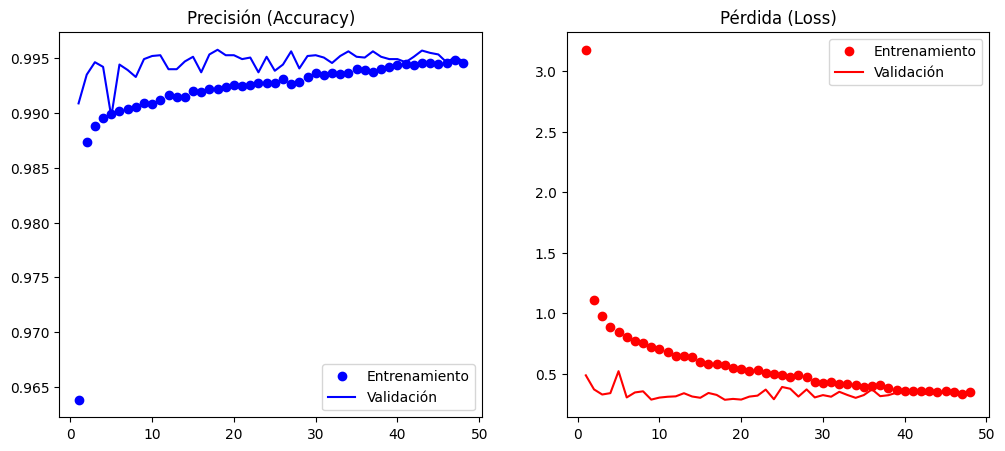

In [ ]:
# =====================================================================
# EJECUCIÓN MAESTRA DEL PIPELINE
# =====================================================================

# 1. Instanciar el modelo
# Usamos tu función y el diccionario CONFIG previamente definido
# modelo = crear_modelo_cnn_lstm(CONFIG)

# 2. Entrenar el modelo
# ¡OJO AQUÍ! Pasamos X_train_aug y y_train_aug (los que tienen el balanceo físico)
print("\n🚀 Iniciando la fase de Entrenamiento...")
historial_entrenamiento = entrenar_modelo(
    modelo = modelo_caidas,
    X_train=X_train_aug,          # Datos con ruido y escalado
    y_train=y_train_aug,          # Etiquetas correspondientes
    X_val=X_val,                  # 10% reservado puro
    y_val=y_val,
    class_weights=pesos_compensatorios,
    batch_size=CONFIG["BATCH_SIZE"],
    epochs=CONFIG["EPOCHS"]
)

# 3. Diagnóstico Visual del Aprendizaje
print("\n📊 Generando gráficas de aprendizaje...")
graficar_historial(historial_entrenamiento)


🎓 Iniciando Evaluación Final ante Notario...

[INFO] Cargando el mejor modelo desde: mejor_modelo_caidas.keras
442/442 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


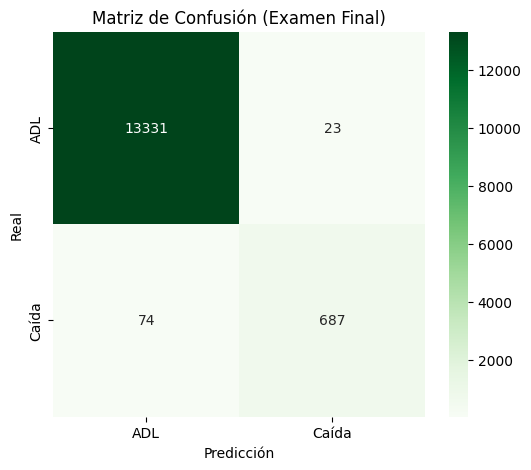


=== Reporte de Clasificación Final (Set de Prueba) ===
              precision    recall  f1-score   support

         ADL       0.99      1.00      1.00     13354
       Caída       0.97      0.90      0.93       761

    accuracy                           0.99     14115
   macro avg       0.98      0.95      0.97     14115
weighted avg       0.99      0.99      0.99     14115



In [ ]:
# 4. Evaluación Final (El "Examen de Grado")
# Usamos X_test y y_test (el otro 10% puro que el modelo jamás ha visto)
print("\n🎓 Iniciando Evaluación Final ante Notario...")
evaluar_modelo(
    modelo_path="mejor_modelo_caidas.keras",
    X_test=X_test,
    y_test=y_test
)

# EVALUACION FORENSE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Cargar el mejor modelo guardado (formato moderno .keras)
modelo_path = "mejor_modelo_caidas.keras"
print(f"⏳ Cargando el cerebro del modelo desde: {modelo_path}...")
modelo_final = tf.keras.models.load_model(modelo_path)

# 2. Generar predicciones probabilísticas sobre el set de Test
print("🔮 Generando inferencias sobre el conjunto de prueba...")
y_pred_probs = modelo_final.predict(X_test)

# Aplanar para evitar problemas de dimensiones en las comparaciones lógicas
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_test_flat = y_test.flatten()

# 3. Identificar matemáticamente los Falsos Negativos
# Realidad = 1 (Caída)  |  Predicción = 0 (ADL)
indices_fn = np.where((y_test_flat == 1) & (y_pred == 0))[0]

print(f"\n🔍 Análisis completado: Se localizaron con precisión los {len(indices_fn)} Falsos Negativos.")

# 4. Bucle para graficar de forma individual las 17 caídas que se escaparon
print("📊 Renderizando los gráficos de las señales temporales...\n")

for i, idx_original in enumerate(indices_fn):
    # Extraer la ventana de tiempo (100 muestras, 6 sensores)
    ventana_temporal = X_test[idx_original]
    probabilidad_calculada = y_pred_probs[idx_original][0]

    # Crear la figura para esta ventana específica
    plt.figure(figsize=(11, 4.5))

    # --- GRÁFICA DEL ACELERÓMETRO (Canales 0, 1, 2) ---
    plt.plot(ventana_temporal[:, 0], label='Acelerómetro X', color='#1f77b4', alpha=0.85, linewidth=1.5)
    plt.plot(ventana_temporal[:, 1], label='Acelerómetro Y', color='#aec7e8', alpha=0.85, linewidth=1.5)
    plt.plot(ventana_temporal[:, 2], label='Acelerómetro Z', color='#ff7f0e', alpha=0.85, linewidth=1.5)

    # --- GRÁFICA DEL GIROSCOPIO (Canales 3, 4, 5) ---
    plt.plot(ventana_temporal[:, 3], label='Giroscopio X', color='#2ca02c', linestyle='--', alpha=0.7)
    plt.plot(ventana_temporal[:, 4], label='Giroscopio Y', color='#98df8a', linestyle='--', alpha=0.7)
    plt.plot(ventana_temporal[:, 5], label='Giroscopio Z', color='#d62728', linestyle='--', alpha=0.7)

    # Títulos y metadatos clínicos del gráfico
    plt.title(f"🚨 FALSO NEGATIVO #{i+1} (Índice original en X_test: {idx_original})\n"
              f"Realidad: CAÍDA | Predicción: ADL | Probabilidad asignada por la red: {probabilidad_calculada:.4f}",
              fontsize=11, fontweight='bold', pad=10)

    plt.xlabel("Línea de Tiempo (Muestras / 50Hz = 2 segundos totales)", fontsize=9)
    plt.ylabel("Amplitud de la Señal (Normalizada)", fontsize=9)

    # Colocar la leyenda fuera del gráfico para que no tape las señales
    plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1.0), fontsize=8, frameon=True)
    plt.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()
    print("-" * 100) # Separador visual en la consola de Colab

⏳ Cargando el cerebro del modelo desde: mejor_modelo_caidas.keras...


TypeError: Could not locate function 'focal_loss_fixed'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'focal_loss_fixed', 'registered_name': 'function'}

Si se fija, normalmente las ventanas muestran caidas pero que son finales o iniciales, las ventanas al cortarlas, alertas atratpan de forma correcta las cuales son.

Para este caso se tiene 154 casos que el modelo detecto como caida pero que no eran, siendo muy atacante.
La conclusion logica es que al momento de etiquetar, el umbral que se uso para decidir si eran caidas o no fue muy poco.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Cargar el modelo entrenado
modelo_path = "mejor_modelo_caidas.keras"
print(f"⏳ Cargando el cerebro del modelo desde: {modelo_path}...")
modelo_final = tf.keras.models.load_model(modelo_path)

# 2. Generar predicciones probabilísticas sobre el set de Test
print("🔮 Generando inferencias sobre el conjunto de prueba...")
y_pred_probs = modelo_final.predict(X_test)

# Aplanar arrays para operaciones lógicas uniformes
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_test_flat = y_test.flatten()

# 3. Identificar matemáticamente los Falsos Positivos
# Realidad = 0 (ADL)  |  Predicción = 1 (Caída)
indices_fp = np.where((y_test_flat == 0) & (y_pred == 1))[0]

print(f"\n🔍 Análisis completado: Se localizaron {len(indices_fp)} Falsos Positivos en el set de prueba.")

# --- CONFIGURACIÓN DE LÍMITE VISUAL ---
# Cambia este número si quieres ver más o menos gráficos en la pantalla de Colab
MAX_GRAFICOS = 15
print(f"📊 Renderizando los primeros {MAX_GRAFICOS} gráficos de falsas alarmas...\n")

for i, idx_original in enumerate(indices_fp[:MAX_GRAVISOS if 'MAX_GRAVISOS' in locals() else MAX_GRAFICOS]):
    # Extraer la ventana de tiempo (100 muestras, 6 sensores)
    ventana_temporal = X_test[idx_original]
    probabilidad_calculada = y_pred_probs[idx_original][0]

    # Crear la figura para esta ventana específica
    plt.figure(figsize=(11, 4.5))

    # --- GRÁFICA DEL ACELERÓMETRO (Canales 0, 1, 2) ---
    plt.plot(ventana_temporal[:, 0], label='Acelerómetro X', color='#1f77b4', alpha=0.85, linewidth=1.5)
    plt.plot(ventana_temporal[:, 1], label='Acelerómetro Y', color='#aec7e8', alpha=0.85, linewidth=1.5)
    plt.plot(ventana_temporal[:, 2], label='Acelerómetro Z', color='#ff7f0e', alpha=0.85, linewidth=1.5)

    # --- GRÁFICA DEL GIROSCOPIO (Canales 3, 4, 5) ---
    plt.plot(ventana_temporal[:, 3], label='Giroscopio X', color='#2ca02c', linestyle='--', alpha=0.7)
    plt.plot(ventana_temporal[:, 4], label='Giroscopio Y', color='#98df8a', linestyle='--', alpha=0.7)
    plt.plot(ventana_temporal[:, 5], label='Giroscopio Z', color='#d62728', linestyle='--', alpha=0.7)

    # Títulos y metadatos del gráfico
    plt.title(f"⚠️ FALSO POSITIVO #{i+1} (Índice original en X_test: {idx_original})\n"
              f"Realidad: ADL (Actividad Cotidiana) | Predicción: CAÍDA | Probabilidad asignada: {probabilidad_calculada:.4f}",
              fontsize=11, fontweight='bold', pad=10)

    plt.xlabel("Línea de Tiempo (Muestras / 50Hz = 2 segundos totales)", fontsize=9)
    plt.ylabel("Amplitud de la Señal (Normalizada)", fontsize=9)

    # Leyenda fuera del gráfico
    plt.legend(loc='upper right', bbox_to_anchor=(1.22, 1.0), fontsize=8, frameon=True)
    plt.grid(True, linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()
    print("-" * 100) # Separador visual en la consola

# CONVERTIR .KERAS EN PTH

Aunque situacional, el siguiente codigo solo es un codigo miscelaneo para uso propio:
Disclaimer: es mejor usar .keras

In [ ]:
pip install tensorflow tf2onnx onnx onnx2torch torch onnxruntime

In [ ]:
import tensorflow as tf
import torch
import torch.nn as nn
import numpy as np

# ==========================================
# 1. DEFINIR LA ARQUITECTURA EXACTA EN PYTORCH
# ==========================================
class ModeloCaidasPyTorch(nn.Module):
    def __init__(self):
        super(ModeloCaidasPyTorch, self).__init__()

        # Conv1D: Entrada=6 sensores, Salida=32 filtros, Kernel=3 (calculado por los 608 params)
        self.conv1 = nn.Conv1d(in_channels=6, out_channels=32, kernel_size=3)
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        # Conv1D: Entrada=32, Salida=64 filtros, Kernel=3 (calculado por los 6208 params)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        self.dropout = nn.Dropout(p=0.5)

        # LSTM: Entrada=64 canales, Salida=64 nodos (calculado por los 33,024 params)
        # batch_first=True es crucial para recibir [Batch, Tiempo, Canales]
        self.lstm = nn.LSTM(input_size=64, hidden_size=64, batch_first=True)

        # Capa Final (Dense)
        self.fc = nn.Linear(in_features=64, out_features=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. Keras recibe (Batch, 100, 6), PyTorch necesita (Batch, 6, 100)
        x = x.transpose(1, 2)

        # Bloque CNN
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)

        # 2. LSTM necesita que el tiempo vuelva al medio: (Batch, Tiempo, 64)
        x = x.transpose(1, 2)
        x = self.dropout(x)

        # Bloque LSTM
        out, (hn, cn) = self.lstm(x)

        # 3. Keras devuelve el último paso de tiempo en las LSTM
        x = out[:, -1, :]

        # Bloque Salida
        x = self.fc(x)
        x = self.sigmoid(x)
        return x

# ==========================================
# 2. CARGAR KERAS Y PREPARAR PYTORCH
# ==========================================
print("Iniciando trasplante de matriz...")
keras_model = tf.keras.models.load_model('mejor_modelo_caidas.keras') # Modo CPU
pt_model = ModeloCaidasPyTorch()

# ==========================================
# 3. INYECTAR PESOS (LA MAGIA MATEMÁTICA)
# ==========================================
with torch.no_grad(): # Desactivamos el entrenamiento mientras inyectamos

    # --- CAPA 1: Conv1D ---
    # Keras: (Kernel, Input, Output) -> PyTorch: (Output, Input, Kernel)
    k_w, k_b = keras_model.get_layer('conv1d_capa_1').get_weights()
    pt_model.conv1.weight.data = torch.tensor(k_w.transpose(2, 1, 0))
    pt_model.conv1.bias.data = torch.tensor(k_b)

    # --- CAPA 2: Conv1D ---
    k_w, k_b = keras_model.get_layer('conv1d_capa_2').get_weights()
    pt_model.conv2.weight.data = torch.tensor(k_w.transpose(2, 1, 0))
    pt_model.conv2.bias.data = torch.tensor(k_b)

    # --- CAPA 3: LSTM ---
    # Keras guarda 3 matrices. PyTorch usa 4 (separa el bias en dos)
    k_lstm_w_ih, k_lstm_w_hh, k_lstm_b = keras_model.get_layer('lstm_temporal').get_weights()

    # Transponemos las matrices principales
    pt_model.lstm.weight_ih_l0.data = torch.tensor(k_lstm_w_ih.T)
    pt_model.lstm.weight_hh_l0.data = torch.tensor(k_lstm_w_hh.T)

    # PyTorch divide el bias en dos (entrada y memoria), Keras usa solo uno.
    pt_model.lstm.bias_ih_l0.data = torch.tensor(k_lstm_b)
    pt_model.lstm.bias_hh_l0.data = torch.zeros_like(pt_model.lstm.bias_ih_l0.data)

    # --- CAPA 4: DENSE (SALIDA) ---
    k_dense_w, k_dense_b = keras_model.get_layer('salida_probabilidad_caida').get_weights()
    pt_model.fc.weight.data = torch.tensor(k_dense_w.T)
    pt_model.fc.bias.data = torch.tensor(k_dense_b)

# ==========================================
# 4. GUARDAR EL MODELO .pth
# ==========================================
ruta_pth = 'modelo_caidas_transplantado.pth'
torch.save(pt_model.state_dict(), ruta_pth)
print(f"✅ ¡Operación exitosa! Modelo PyTorch guardado como: {ruta_pth}")

In [ ]:
keras_model.summary()